In [229]:
#don't change this cell
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [230]:
#don't change this cell
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [231]:
import numpy as np
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.startswith("cuda"):
    torch.cuda.manual_seed_all(seed)

In [232]:
#TODO
FILE_PATH = r".\diabetes.csv"

In [233]:
# #don't change this cell
df = pd.read_csv(FILE_PATH, header=0)

# Rename Outcome to Diagnosis and convert to binary (already 0/1)
df = df.rename(columns={"Outcome": "Diagnosis"})

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# preprocessing

In [234]:
df['Diagnosis'].value_counts()

Diagnosis
0    500
1    268
Name: count, dtype: int64

In [235]:
# df['Insulin'].hist(bins=50)
# plt.xlabel('Insulin')

In [236]:
# df[df['BMI'] == 0.0] = df['BMI'].mean()
# df[df['BloodPressure'] == 0.0] = df['BloodPressure'].median()
# df[df['Glucose'] == 0.0] = df['Glucose'].median()

# df[df['Insulin'] == 0.0] = df['Insulin'].mean()
# df[df['SkinThickness'] == 0.0] = df['SkinThickness'].mean()

columns_to_fix_med = ['Glucose', 'BloodPressure']
columns_to_fix_mea = ['BMI','SkinThickness','Insulin']

for col in columns_to_fix_mea:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    mean_value = df[col].mean()
    df[col] = df[col].replace(np.nan, mean_value)
    
for col in columns_to_fix_med:
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    
    median_value = df[col].median()
    df[col] = df[col].replace(np.nan, median_value)
    

In [237]:
df.shape

(768, 9)

In [238]:
# don't change this cell
X = df.drop(columns=["Diagnosis"]).values
y = df["Diagnosis"].values

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [239]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)


scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_val, y_val)
test_dataset_org = TensorDataset(X_test, y_test)

C:\Users\asus\AppData\Local\Temp\ipykernel_7768\2428031402.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
C:\Users\asus\AppData\Local\Temp\ipykernel_7768\2428031402.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
C:\Users\asus\AppData\Local\Temp\ipykernel_7768\2428031402.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


In [240]:
#TODO
train_loader = DataLoader(train_dataset,
                          batch_size=64,
                          shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=64,
                         shuffle=False )



In [241]:
#TODO
class MLP(nn.Module):
    def __init__(self, input_size, dropout_p=0.5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size,32), 
            nn.BatchNorm1d(32),
            nn.ReLU(), 
            nn.Dropout(dropout_p),                
            
            nn.Linear(32, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),      
            
            nn.Linear(64, 16), 
            nn.BatchNorm1d(16),
            nn.ReLU(),      
            nn.Dropout(dropout_p * 0.6),   

            nn.Linear(16, 1),          
            # nn.Sigmoid()               
        )
    def forward(self, x):
        return self.model(x)

In [242]:
#TODO
input_size = X.shape[1]
model = MLP(input_size,dropout_p=0.4).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
NUM_EPOCHS = 90

In [243]:
metrics_df = pd.DataFrame(columns=["Epoch", 
                                   "Train_Loss", "Train_Accuracy", 
                                #    "Val_Loss", 
                                   "Val_Accuracy"])


In [244]:
train_accuracy_list= []
test_accuracy_list= []

#TODO
for epoch in range(NUM_EPOCHS):
    model.train()
    total=0
    corrects= 0
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs= inputs.to(device)
        labels= labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() 
        total += labels.size(0)
        outputs=torch.sigmoid(outputs)
        predicted = (outputs > 0.5).float()
        corrects += (predicted == labels).sum().item()

    train_accuracy= corrects / total
    train_loss = running_loss / len(train_loader)
    train_accuracy_list.append(train_accuracy)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {train_loss:.4f}, Acurracy= {train_accuracy:.4f}")

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs= inputs.to(device)
            labels= labels.to(device)
            # loss = criterion(model(inputs), labels)
            # val_loss = loss.item()
            
            outputs = model(inputs)
            outputs=torch.sigmoid(outputs)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    test_accuracy_list.append(accuracy)
    

    metrics_df = pd.concat([metrics_df, 
                            pd.DataFrame.from_dict([{
                                "Epoch": epoch+1,
                                "Train_Loss": train_loss,
                                "Train_Accuracy": train_accuracy,
                                # "Val_Loss": val_loss,
                                "Val_Accuracy": accuracy
                            }])], ignore_index=True)
     
    print(f"Test Accuracy: {accuracy:.4f}", end="\n\n")

Epoch 1/90, Loss: 0.6425, Acurracy= 0.6326
Test Accuracy: 0.6688

Epoch 2/90, Loss: 0.5985, Acurracy= 0.6630
Test Accuracy: 0.7013

Epoch 3/90, Loss: 0.5905, Acurracy= 0.7000
Test Accuracy: 0.7208

Epoch 4/90, Loss: 0.5540, Acurracy= 0.6978
Test Accuracy: 0.7403

Epoch 5/90, Loss: 0.5476, Acurracy= 0.7022
Test Accuracy: 0.7597

Epoch 6/90, Loss: 0.5298, Acurracy= 0.7283
Test Accuracy: 0.7532

Epoch 7/90, Loss: 0.5392, Acurracy= 0.7022
Test Accuracy: 0.7532



C:\Users\asus\AppData\Local\Temp\ipykernel_7768\1106686507.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df,


Epoch 8/90, Loss: 0.5168, Acurracy= 0.7326
Test Accuracy: 0.7662

Epoch 9/90, Loss: 0.5179, Acurracy= 0.7326
Test Accuracy: 0.7597

Epoch 10/90, Loss: 0.5008, Acurracy= 0.7261
Test Accuracy: 0.7532

Epoch 11/90, Loss: 0.5044, Acurracy= 0.7413
Test Accuracy: 0.7532

Epoch 12/90, Loss: 0.5096, Acurracy= 0.7543
Test Accuracy: 0.7597

Epoch 13/90, Loss: 0.4969, Acurracy= 0.7152
Test Accuracy: 0.7662

Epoch 14/90, Loss: 0.4910, Acurracy= 0.7391
Test Accuracy: 0.7727

Epoch 15/90, Loss: 0.4852, Acurracy= 0.7348
Test Accuracy: 0.7727

Epoch 16/90, Loss: 0.4886, Acurracy= 0.7370
Test Accuracy: 0.7662

Epoch 17/90, Loss: 0.4656, Acurracy= 0.7587
Test Accuracy: 0.7662

Epoch 18/90, Loss: 0.4914, Acurracy= 0.7587
Test Accuracy: 0.7597

Epoch 19/90, Loss: 0.4868, Acurracy= 0.7609
Test Accuracy: 0.7662

Epoch 20/90, Loss: 0.4748, Acurracy= 0.7609
Test Accuracy: 0.7532

Epoch 21/90, Loss: 0.4586, Acurracy= 0.7370
Test Accuracy: 0.7597

Epoch 22/90, Loss: 0.4757, Acurracy= 0.7739
Test Accuracy: 0.759

In [245]:
print(metrics_df)

   Epoch  Train_Loss  Train_Accuracy  Val_Accuracy
0      1    0.642546        0.632609      0.668831
1      2    0.598514        0.663043      0.701299
2      3    0.590470        0.700000      0.720779
3      4    0.554039        0.697826      0.740260
4      5    0.547556        0.702174      0.759740
..   ...         ...             ...           ...
85    86    0.380568        0.808696      0.779221
86    87    0.370054        0.810870      0.785714
87    88    0.363276        0.815217      0.746753
88    89    0.352851        0.832609      0.740260
89    90    0.365804        0.834783      0.779221

[90 rows x 4 columns]


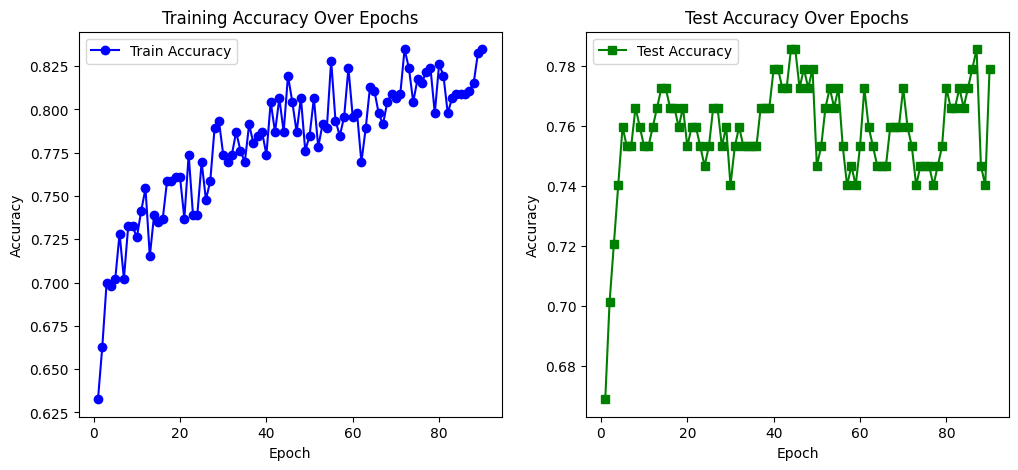

In [246]:
# don't change this cell
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_accuracy_list, marker='o', linestyle='-', color='b', label="Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), test_accuracy_list, marker='s', linestyle='-', color='g', label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy Over Epochs")
plt.legend()

plt.show()

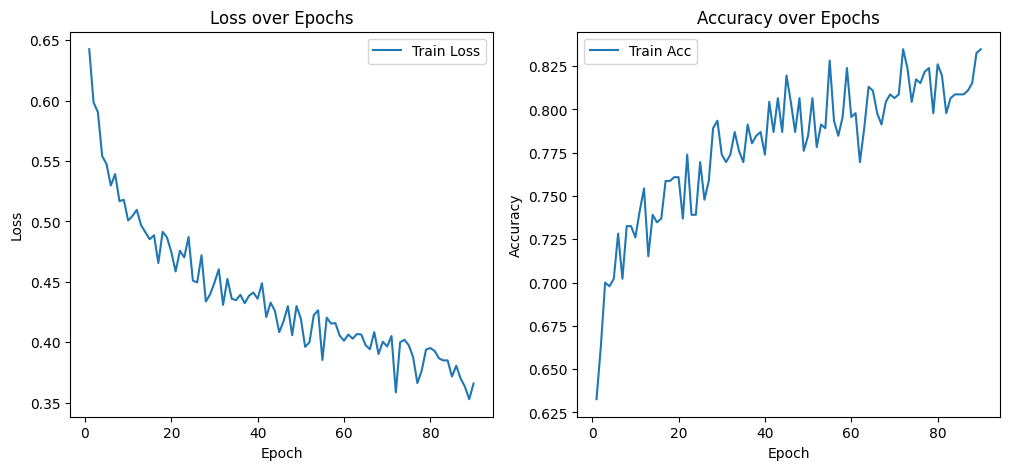

In [ ]:
# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# plt.plot(metrics_df['Epoch'], metrics_df['Train_Loss'], label='Train Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss over Epochs')
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(metrics_df['Epoch'], metrics_df['Train_Accuracy'], label='Train Acc')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.title('Accuracy over Epochs')
# plt.legend()

# plt.show()
